# UMLS vs Schema-Guided Graph Comparison

This notebook compares the two UMLS-based index configurations that matter for this experiment:

- `use_umls=True`, `schema_guided=False`
- `use_umls=True`, `schema_guided=True`

It keeps the models fixed to `gemma4:latest` and `qwen3-embedding:0.6b`, renders one graph per condition, and evaluates each condition at three levels:

- graph structure quality
- retrieval quality
- question-answering quality


In [1]:
from __future__ import annotations

import asyncio
import json
import os
import sys
from html import escape
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from pydantic import BaseModel, Field
from dotenv import load_dotenv

repo_root = Path.cwd()
if not (repo_root / "main.py").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.chdir(repo_root)

load_dotenv()

from eval.embedding_benchmark import (
    discover_questions_path,
    filter_questions_by_note_overlap,
    load_all_questions,
    load_benchmark_questions,
)
from eval.medqa_smoke import extract_answer, format_options
from eval.metrics import exact_match_score
from helpers.ollama import ollama_endpoint
from retrieval.index import ensure_index
from retrieval.query import query_index_with_diagnostics
from llama_index.core.prompts import PromptTemplate
from llama_index.llms.ollama import Ollama
from retrieval.visualize import _load_graph_tables, save_clinical_entity_graph, save_clinical_entity_graph_jpeg

GENERATION_MODEL = "gemma4:latest"
EMBEDDING_MODEL = "qwen3-embedding:0.6b"
JUDGE_MODEL = os.environ.get("JUDGE_MODEL", GENERATION_MODEL)
JUDGE_REQUEST_TIMEOUT = float(os.environ.get("JUDGE_LLM_REQUEST_TIMEOUT", "180"))
INPUT_DIR = Path(os.environ.get("INPUT_BASE_DIR", "data/evidence/mimic_discharge_subset"))
OUTPUT_ROOT = Path("output/umls_schema_comparison")
SAMPLE_SIZE = 10
SIMILARITY_TOP_K = 5
REQUIRE_QUESTION_NOTE_OVERLAP = True
MIN_OVERLAP_TERMS = 2
GRAPH_SOURCE = "auto"
MAX_GRAPH_NODES = 80
MAX_GRAPH_EDGES = 160

CONDITIONS = [
    {"label": "umls_only", "use_umls": True, "schema_guided": False, "title": "UMLS only"},
    {"label": "umls_and_schema", "use_umls": True, "schema_guided": True, "title": "UMLS + Schema"},
]

REPORT_ROOT = OUTPUT_ROOT / "report"
FIGURE_ROOT = REPORT_ROOT / "figures"
TABLE_ROOT = REPORT_ROOT / "tables"

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
REPORT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)
print(json.dumps({
    "repo_root": str(repo_root),
    "input_dir": str(INPUT_DIR),
    "output_root": str(OUTPUT_ROOT),
    "report_root": str(REPORT_ROOT),
    "generation_model": GENERATION_MODEL,
    "embedding_model": EMBEDDING_MODEL,
    "judge_model": JUDGE_MODEL,
    "sample_size": SAMPLE_SIZE,
}, indent=2))


/Users/oluwatosinoso/Library/CloudStorage/OneDrive-hull.ac.uk/argumentation_schemes/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{
  "repo_root": "/Users/oluwatosinoso/Library/CloudStorage/OneDrive-hull.ac.uk/argumentation_schemes",
  "input_dir": "data/evidence/mimic_discharge_subset",
  "output_root": "output/umls_schema_comparison",
  "report_root": "output/umls_schema_comparison/report",
  "generation_model": "gemma4:latest",
  "embedding_model": "qwen3-embedding:0.6b",
  "judge_model": "gemma4:latest",
  "sample_size": 10
}


## Evaluation Design

Visual inspection is useful, but it is not enough on its own. A graph can look busy and still be worse for retrieval.

This notebook therefore checks:

- **Structure:** node count, edge count, density, component count, isolate count, entity type diversity, edge overlap.
- **Retrieval:** source count, retrieval scores, cosine similarity to retrieved context, score margins.
- **Task performance:** exact match on a fixed question set under the same generation and embedding models.

The most important comparison is not just each absolute graph, but the difference between conditions: which nodes and edges are added, and whether those additions help answer questions or only add noise.


In [2]:
def configure_models() -> None:
    os.environ["INDEX_LLM_PROVIDER"] = "ollama"
    os.environ["INDEX_EMBEDDING_PROVIDER"] = "ollama"
    os.environ["INDEX_LLM_MODEL"] = GENERATION_MODEL
    os.environ["INDEX_EMBEDDING_MODEL"] = EMBEDDING_MODEL


def assert_umls_ready() -> None:
    needs_umls = any(condition["use_umls"] for condition in CONDITIONS)
    if not needs_umls:
        return
    if not os.environ.get("UMLS_API_KEY"):
        raise RuntimeError("UMLS_API_KEY is required for the UMLS-enabled conditions in this notebook.")
    os.environ["UMLS_ENABLED"] = "true"


def run_async(coro):
    try:
        loop = asyncio.get_running_loop()
    except RuntimeError:
        return asyncio.run(coro)
    import nest_asyncio
    nest_asyncio.apply()
    return loop.run_until_complete(coro)


report_sections: list[dict[str, str]] = []
_judge_llm = None


class JudgeResult(BaseModel):
    score: float = Field(..., ge=0.0, le=5.0)
    verdict: str
    rationale: str


JUDGE_PROMPT = PromptTemplate(
    """You are grading a clinical QA response against a reference answer.\n"""
    """Score the model answer from 0.0 to 5.0 using the reference answer as the main standard.\n"""
    """Give higher scores to answers that are clinically correct, complete enough, and aligned with the reference.\n"""
    """A partially correct answer can receive an intermediate score.\n"""
    """Return JSON only with fields: score, verdict, rationale.\n\n"""
    """Question: {question}\n\n"""
    """Reference answer: {reference_answer}\n\n"""
    """Model answer: {model_answer}\n"""
)


def get_judge_llm():
    global _judge_llm
    if _judge_llm is None:
        _judge_llm = Ollama(
            model=JUDGE_MODEL,
            base_url=ollama_endpoint(),
            request_timeout=JUDGE_REQUEST_TIMEOUT,
        )
    return _judge_llm


def judge_response_against_reference(question: str, reference_answer: str | None, model_answer: str | None) -> dict[str, object]:
    if not reference_answer or not model_answer:
        return {
            "judge_score": np.nan,
            "judge_verdict": None,
            "judge_rationale": None,
        }
    try:
        result = get_judge_llm().structured_predict(
            JudgeResult,
            JUDGE_PROMPT,
            question=question,
            reference_answer=reference_answer,
            model_answer=model_answer,
        )
        return {
            "judge_score": float(result.score),
            "judge_verdict": str(result.verdict),
            "judge_rationale": str(result.rationale),
        }
    except Exception as exc:
        return {
            "judge_score": np.nan,
            "judge_verdict": "error",
            "judge_rationale": str(exc),
        }


def report_rel(path: Path) -> str:
    return path.relative_to(REPORT_ROOT).as_posix()


def save_figure(fig, stem: str) -> Path:
    path = FIGURE_ROOT / f"{stem}.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    return path


def save_dataframe_artifacts(frame: pd.DataFrame, stem: str, *, index: bool = False) -> tuple[Path, Path]:
    csv_path = TABLE_ROOT / f"{stem}.csv"
    html_path = TABLE_ROOT / f"{stem}.html"
    frame.to_csv(csv_path, index=index)
    html_path.write_text(frame.to_html(index=index), encoding="utf-8")
    return csv_path, html_path


def save_html_fragment(stem: str, title: str, body_html: str) -> Path:
    path = TABLE_ROOT / f"{stem}.html"
    path.write_text(
        "<!DOCTYPE html><html><head><meta charset='utf-8'><title>" + escape(title) + "</title>"
        + "<style>body{font-family:Arial,sans-serif;margin:24px;}table{border-collapse:collapse;width:100%;}"
        + "th,td{border:1px solid #d1d5db;padding:8px;text-align:left;vertical-align:top;}"
        + "th{background:#f3f4f6;}h1,h2{color:#111827;}img{max-width:100%;height:auto;}</style></head><body>"
        + f"<h1>{escape(title)}</h1>{body_html}</body></html>",
        encoding="utf-8",
    )
    return path


def add_report_section(title: str, body_html: str) -> None:
    report_sections.append({"title": title, "body": body_html})


def write_report_html() -> Path:
    section_html = []
    for section in report_sections:
        section_html.append(f"<section><h2>{escape(section['title'])}</h2>{section['body']}</section>")
    report_path = REPORT_ROOT / "index.html"
    report_path.write_text(
        "<!DOCTYPE html><html><head><meta charset='utf-8'><title>UMLS Schema Comparison</title>"
        + "<style>body{font-family:Arial,sans-serif;margin:32px;color:#111827;line-height:1.5;}"
        + "section{margin-bottom:32px;}table{border-collapse:collapse;width:100%;}"
        + "th,td{border:1px solid #d1d5db;padding:8px;text-align:left;vertical-align:top;}"
        + "th{background:#f3f4f6;}img{max-width:100%;height:auto;border:1px solid #d1d5db;}"
        + "ul{padding-left:20px;}code{background:#f3f4f6;padding:2px 4px;border-radius:4px;}</style></head><body>"
        + "<h1>UMLS vs Schema-Guided Graph Comparison</h1>"
        + "".join(section_html)
        + "</body></html>",
        encoding="utf-8",
    )
    return report_path


def condition_output_dir(condition: dict[str, object]) -> Path:
    return OUTPUT_ROOT / str(condition["label"])


def condition_summary(condition: dict[str, object]) -> str:
    return f"{condition['title']} | use_umls={condition['use_umls']} | schema_guided={condition['schema_guided']}"


def build_condition(condition: dict[str, object]):
    configure_models()
    output_dir = condition_output_dir(condition)
    output_dir.mkdir(parents=True, exist_ok=True)
    index = ensure_index(
        input_dir=INPUT_DIR,
        output_dir=output_dir,
        use_umls=bool(condition["use_umls"]),
        schema_guided=bool(condition["schema_guided"]),
    )
    image_path = save_clinical_entity_graph_jpeg(
        output_dir=output_dir,
        jpeg_path=output_dir / "graph.jpg",
        source=GRAPH_SOURCE,
        max_nodes=MAX_GRAPH_NODES,
        max_edges=MAX_GRAPH_EDGES,
        title=str(condition["title"]),
    )
    html_graph_path = save_clinical_entity_graph(
        output_dir=output_dir,
        html_path=output_dir / "graph.html",
        source=GRAPH_SOURCE,
        max_nodes=MAX_GRAPH_NODES,
        max_edges=MAX_GRAPH_EDGES,
    )
    entities, relationships = _load_graph_tables(output_dir, source=GRAPH_SOURCE)
    return {
        "condition": condition,
        "index": index,
        "output_dir": output_dir,
        "image_path": image_path,
        "html_graph_path": html_graph_path,
        "entities": entities.copy(),
        "relationships": relationships.copy(),
    }


def build_graph_frames(entities: pd.DataFrame, relationships: pd.DataFrame) -> nx.Graph:
    graph = nx.Graph()
    if not entities.empty:
        for row in entities.fillna("").itertuples(index=False):
            title = str(getattr(row, "title", "")).strip()
            if not title:
                continue
            graph.add_node(title, entity_type=str(getattr(row, "type", "UNKNOWN") or "UNKNOWN"))
    if not relationships.empty:
        for row in relationships.fillna("").itertuples(index=False):
            source = str(getattr(row, "source", "")).strip()
            target = str(getattr(row, "target", "")).strip()
            if not source or not target:
                continue
            graph.add_edge(source, target, weight=float(getattr(row, "weight", 1.0) or 1.0))
    return graph


def edge_set(relationships: pd.DataFrame) -> set[tuple[str, str]]:
    if relationships.empty:
        return set()
    pairs = set()
    for row in relationships.fillna("").itertuples(index=False):
        source = str(getattr(row, "source", "")).strip()
        target = str(getattr(row, "target", "")).strip()
        if source and target:
            pairs.add(tuple(sorted((source, target))))
    return pairs


def jaccard(left: set, right: set) -> float:
    union = left | right
    if not union:
        return 1.0
    return len(left & right) / len(union)


def graph_stats(label: str, entities: pd.DataFrame, relationships: pd.DataFrame) -> dict[str, object]:
    graph = build_graph_frames(entities, relationships)
    node_count = graph.number_of_nodes()
    edge_count = graph.number_of_edges()
    component_count = nx.number_connected_components(graph) if node_count else 0
    isolates = nx.number_of_isolates(graph) if node_count else 0
    largest_component = max((len(component) for component in nx.connected_components(graph)), default=0) if node_count else 0
    density = nx.density(graph) if node_count > 1 else 0.0
    entity_types = 0
    if not entities.empty and "type" in entities.columns:
        entity_types = int(entities["type"].fillna("UNKNOWN").astype(str).str.upper().nunique())
    return {
        "condition": label,
        "node_count": node_count,
        "edge_count": edge_count,
        "density": round(float(density), 4),
        "component_count": component_count,
        "largest_component_share": round((largest_component / node_count) if node_count else 0.0, 4),
        "isolate_count": isolates,
        "isolate_share": round((isolates / node_count) if node_count else 0.0, 4),
        "entity_type_count": entity_types,
    }


def load_questions_for_comparison(sample_size: int = SAMPLE_SIZE) -> list[dict[str, object]]:
    questions_path = discover_questions_path(None)
    if questions_path is None:
        return load_benchmark_questions(None, sample_size=sample_size)
    raw_questions = load_all_questions(questions_path)
    if not REQUIRE_QUESTION_NOTE_OVERLAP:
        return raw_questions[:sample_size]
    selected, overlap_details = filter_questions_by_note_overlap(
        questions=raw_questions,
        input_dir=INPUT_DIR,
        max_questions=sample_size,
        min_overlap_terms=MIN_OVERLAP_TERMS,
    )
    if not selected:
        raise RuntimeError(
            f"No overlapping benchmark questions found for {INPUT_DIR} with min_overlap_terms={MIN_OVERLAP_TERMS}."
        )
    overlap_path = OUTPUT_ROOT / "selected_questions.json"
    overlap_path.write_text(json.dumps(overlap_details, indent=2), encoding="utf-8")
    return selected


async def benchmark_condition(index, questions: list[dict[str, object]]) -> tuple[pd.DataFrame, dict[str, float | int | None]]:
    rows = []
    for item in questions:
        question_text = str(item.get("question", ""))
        options = item.get("options") or {}
        prompt = question_text
        if options:
            prompt = f"{question_text}\n\n{format_options(options)}"
        response, context, diagnostics = await query_index_with_diagnostics(
            index=index,
            query=prompt,
            similarity_top_k=SIMILARITY_TOP_K,
        )
        predicted = extract_answer(response, options) if options else None
        expected = item.get("answer")
        expected_text = options.get(expected, expected) if isinstance(options, dict) else expected
        judge_scores = await asyncio.to_thread(
            judge_response_against_reference,
            question_text,
            expected_text,
            response,
        )
        rows.append({
            "question": question_text,
            "expected_answer": expected_text,
            "predicted_answer": predicted,
            "exact_match": exact_match_score(predicted, expected_text) if expected_text else np.nan,
            "response": response,
            "context_preview": context[:1200],
            **judge_scores,
            **diagnostics,
        })
    frame = pd.DataFrame(rows)
    summary = {
        "question_count": int(len(frame)),
        "exact_match": float(frame["exact_match"].dropna().mean()) if "exact_match" in frame else np.nan,
        "mean_judge_score": float(frame["judge_score"].dropna().mean()) if "judge_score" in frame else np.nan,
        "mean_source_count": float(frame["source_count"].mean()) if "source_count" in frame else np.nan,
        "mean_top_retrieval_score": float(frame["top_retrieval_score"].dropna().mean()) if "top_retrieval_score" in frame else np.nan,
        "mean_retrieval_score": float(frame["mean_retrieval_score"].dropna().mean()) if "mean_retrieval_score" in frame else np.nan,
        "mean_retrieval_score_margin": float(frame["retrieval_score_margin"].dropna().mean()) if "retrieval_score_margin" in frame else np.nan,
        "mean_top_cosine_similarity": float(frame["top_cosine_similarity"].dropna().mean()) if "top_cosine_similarity" in frame else np.nan,
        "mean_cosine_similarity": float(frame["mean_cosine_similarity"].dropna().mean()) if "mean_cosine_similarity" in frame else np.nan,
        "mean_cosine_similarity_margin": float(frame["cosine_similarity_margin"].dropna().mean()) if "cosine_similarity_margin" in frame else np.nan,
    }
    return frame, summary


def select_condition_winner(frame: pd.DataFrame) -> str | None:
    if frame.empty:
        return None
    ranked = frame.copy()
    ranked["judge_rank"] = pd.to_numeric(ranked.get("judge_score"), errors="coerce").fillna(-1.0)
    ranked["exact_match_rank"] = pd.to_numeric(ranked.get("exact_match"), errors="coerce").fillna(-1.0)
    ranked["retrieval_rank"] = pd.to_numeric(ranked.get("top_retrieval_score"), errors="coerce").fillna(-1.0)
    ranked["cosine_rank"] = pd.to_numeric(ranked.get("top_cosine_similarity"), errors="coerce").fillna(-1.0)
    ranked = ranked.sort_values(
        by=["judge_rank", "exact_match_rank", "retrieval_rank", "cosine_rank", "condition"],
        ascending=[False, False, False, False, True],
        kind="stable",
    )
    return str(ranked.iloc[0]["condition"]) if not ranked.empty else None


assert INPUT_DIR.exists(), f"Input directory does not exist: {INPUT_DIR}"
configure_models()
assert_umls_ready()


### Building UMLS only | use_umls=True | schema_guided=False

Using existing LlamaIndex property graph in output/umls_schema_comparison/umls_only


### Building UMLS + Schema | use_umls=True | schema_guided=True

Using existing LlamaIndex property graph in output/umls_schema_comparison/umls_and_schema


## Graph Images

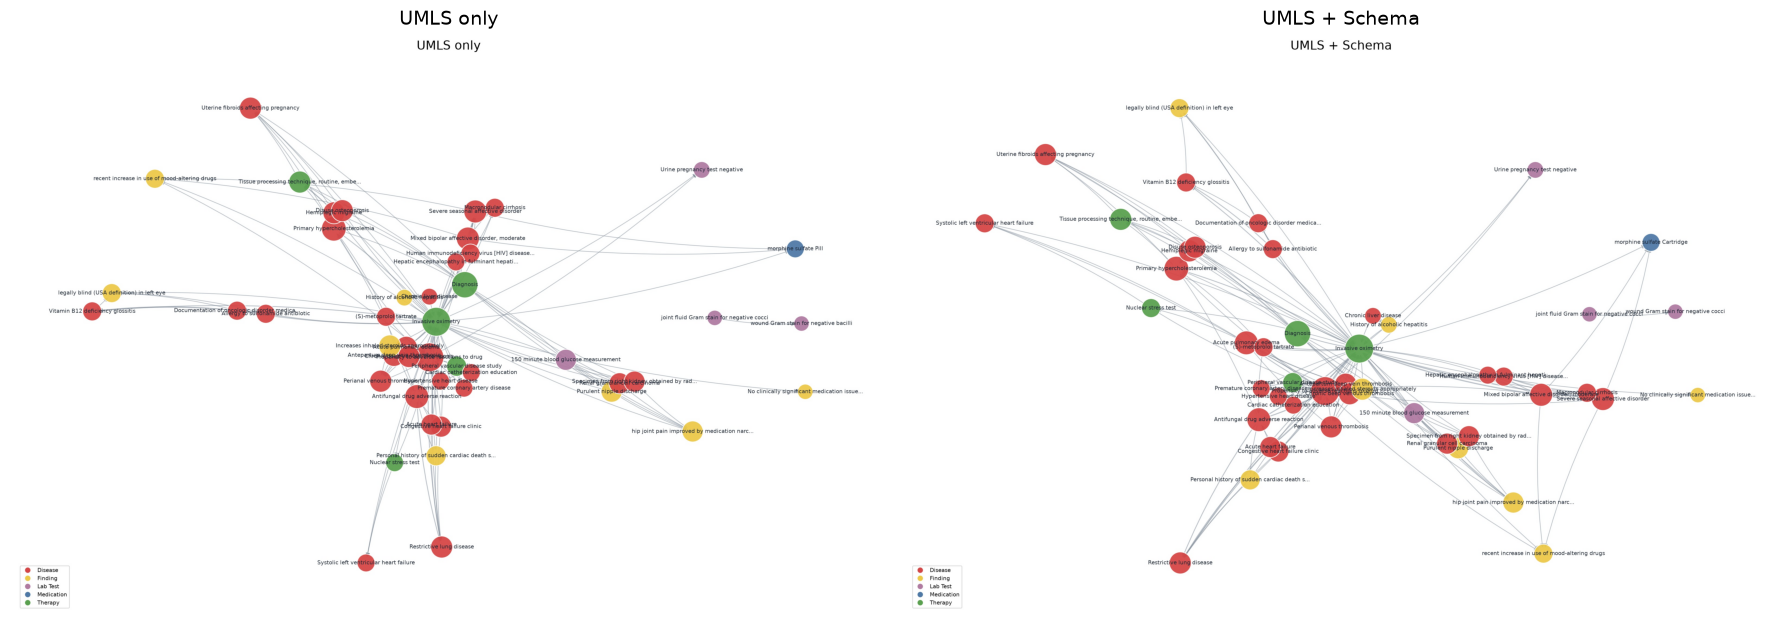

,condition,node_count,edge_count,density,component_count,largest_component_share,isolate_count,isolate_share,entity_type_count
0,umls_and_schema,49,161,0.1369,2,0.9592,0,0.0,6
1,umls_only,49,159,0.1352,2,0.9592,0,0.0,6


In [3]:
artifacts = []
for condition in CONDITIONS:
    display(Markdown(f"### Building {condition_summary(condition)}"))
    artifacts.append(build_condition(condition))

display(Markdown("## Graph Images"))
fig, axes = plt.subplots(1, len(artifacts), figsize=(9 * max(1, len(artifacts)), 7))
axes = np.atleast_1d(axes)
for axis, artifact in zip(axes, artifacts):
    axis.imshow(plt.imread(artifact["image_path"]))
    axis.set_title(str(artifact["condition"]["title"]), fontsize=14)
    axis.axis("off")
for axis in axes[len(artifacts):]:
    axis.axis("off")
fig.tight_layout()
graph_gallery_path = save_figure(fig, "01_graph_gallery")
plt.show()

graph_stats_df = pd.DataFrame([
    graph_stats(str(artifact["condition"]["label"]), artifact["entities"], artifact["relationships"])
    for artifact in artifacts
]).sort_values("condition").reset_index(drop=True)
graph_stats_csv_path, graph_stats_html_path = save_dataframe_artifacts(graph_stats_df, "graph_stats")

condition_links = "".join(
    f"<li><strong>{escape(str(artifact['condition']['title']))}</strong>: "
    f"<a href='../{artifact['condition']['label']}/graph.jpg'>jpg</a> | "
    f"<a href='../{artifact['condition']['label']}/graph.html'>html</a></li>"
    for artifact in artifacts
)
add_report_section(
    "Graph Images",
    f"<p><img src='{report_rel(graph_gallery_path)}' alt='Graph gallery'></p>"
    f"<p><a href='{report_rel(graph_stats_html_path)}'>Graph stats table</a> | "
    f"<a href='{report_rel(graph_stats_csv_path)}'>CSV</a></p><ul>{condition_links}</ul>",
)
graph_stats_df


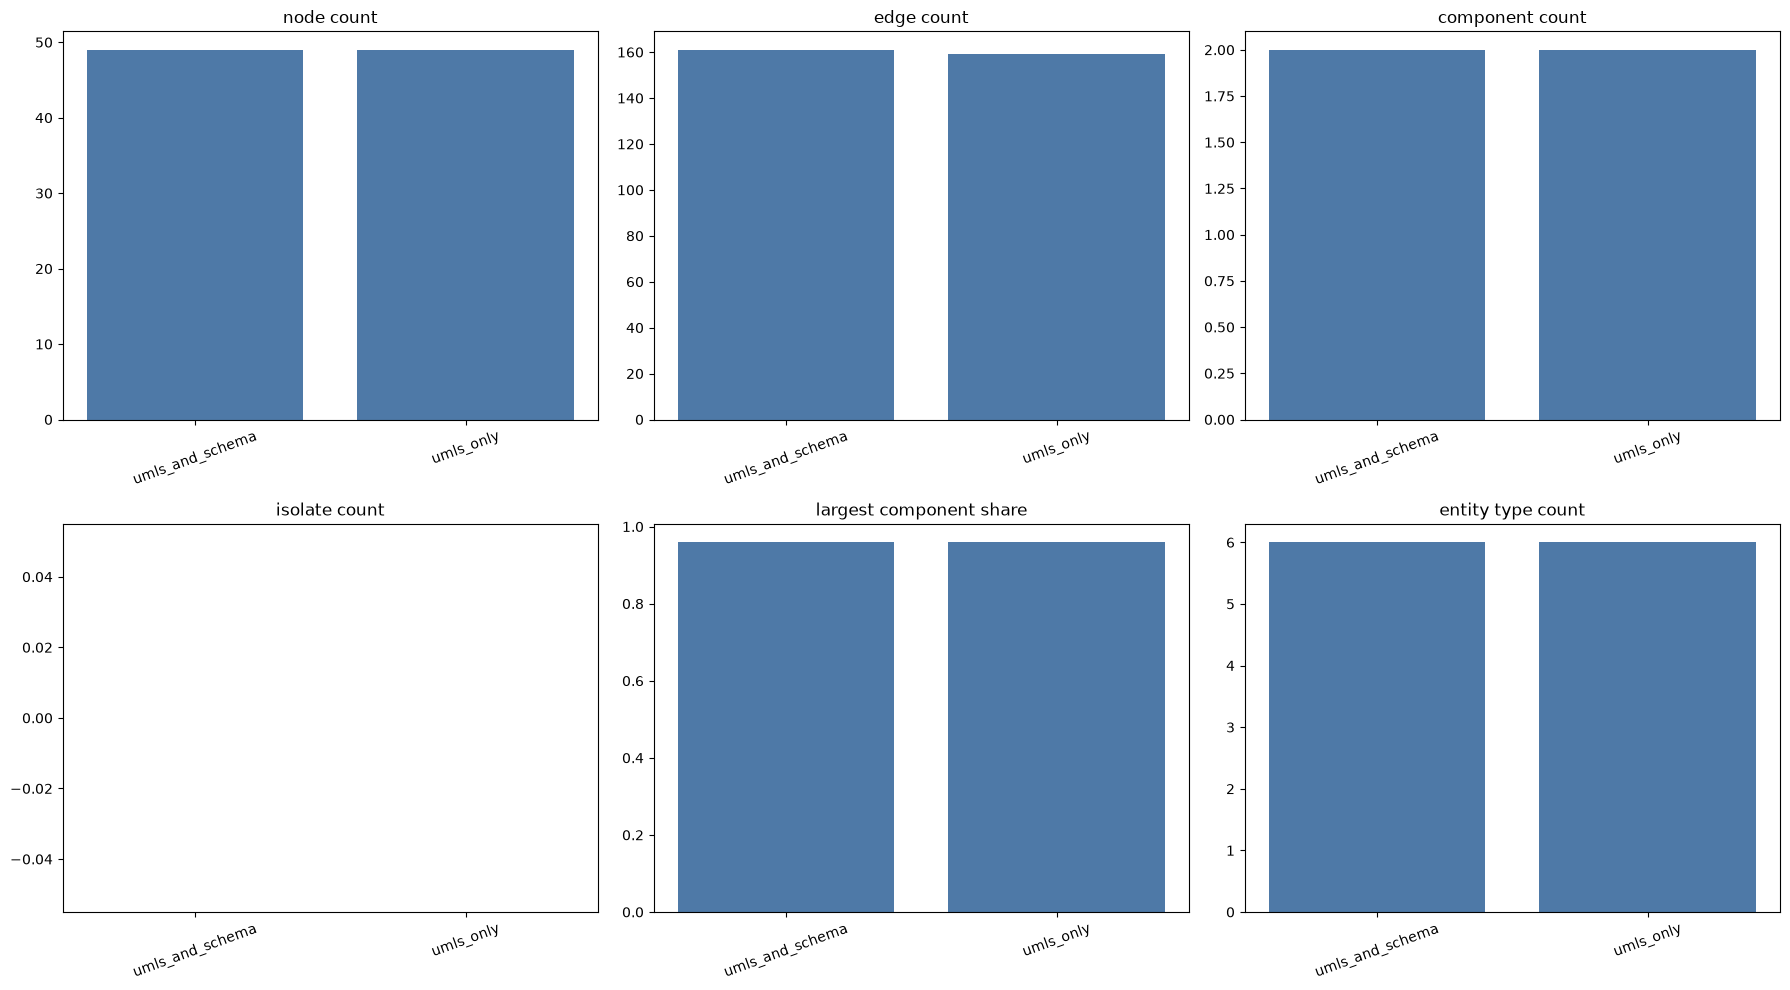

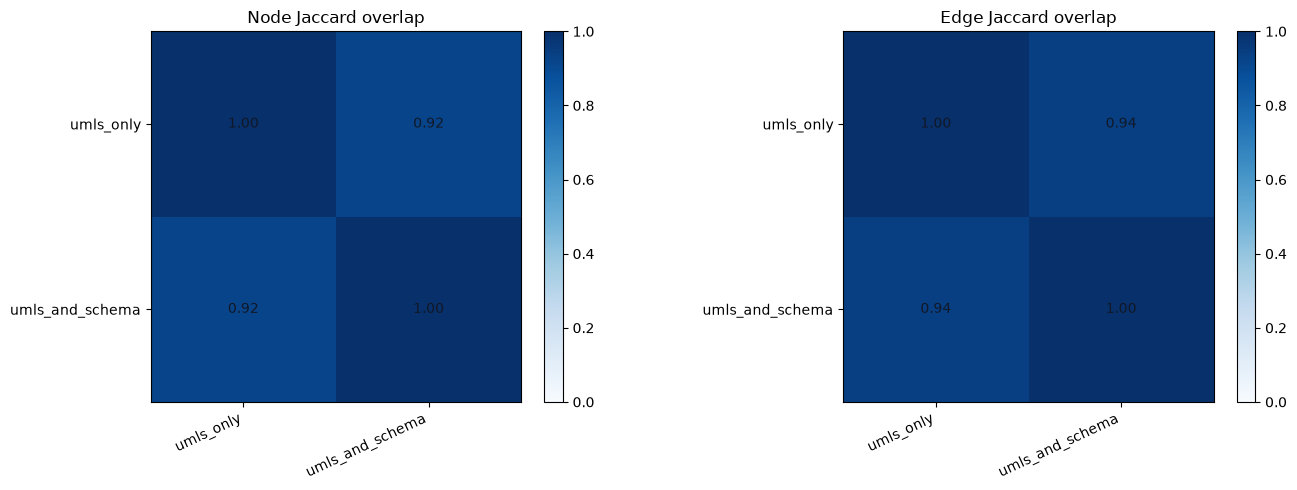

(<pandas.io.formats.style.Styler at 0x1363e2840>,
 <pandas.io.formats.style.Styler at 0x1362f4b30>)

In [4]:
plot_columns = [
    "node_count",
    "edge_count",
    "component_count",
    "isolate_count",
    "largest_component_share",
    "entity_type_count",
]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for axis, column in zip(axes.flat, plot_columns):
    axis.bar(graph_stats_df["condition"], graph_stats_df[column], color="#4e79a7")
    axis.set_title(column.replace("_", " "))
    axis.tick_params(axis="x", rotation=20)
fig.tight_layout()
graph_metrics_path = save_figure(fig, "02_graph_metrics")
plt.show()

labels = [str(artifact["condition"]["label"]) for artifact in artifacts]
node_sets = {
    str(artifact["condition"]["label"]): set(artifact["entities"].get("title", pd.Series(dtype=str)).dropna().astype(str))
    for artifact in artifacts
}
edge_sets = {
    str(artifact["condition"]["label"]): edge_set(artifact["relationships"])
    for artifact in artifacts
}

node_overlap = pd.DataFrame(index=labels, columns=labels, dtype=float)
edge_overlap = pd.DataFrame(index=labels, columns=labels, dtype=float)
for left in labels:
    for right in labels:
        node_overlap.loc[left, right] = jaccard(node_sets[left], node_sets[right])
        edge_overlap.loc[left, right] = jaccard(edge_sets[left], edge_sets[right])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, matrix, title in [
    (axes[0], node_overlap, "Node Jaccard overlap"),
    (axes[1], edge_overlap, "Edge Jaccard overlap"),
]:
    image = axis.imshow(matrix.values, cmap="Blues", vmin=0, vmax=1)
    axis.set_xticks(range(len(labels)), labels, rotation=25, ha="right")
    axis.set_yticks(range(len(labels)), labels)
    axis.set_title(title)
    for i in range(len(labels)):
        for j in range(len(labels)):
            axis.text(j, i, f"{matrix.iloc[i, j]:.2f}", ha="center", va="center", color="#111827")
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
fig.tight_layout()
overlap_heatmap_path = save_figure(fig, "03_overlap_heatmaps")
plt.show()

node_overlap_csv_path, node_overlap_html_path = save_dataframe_artifacts(node_overlap.reset_index(names="condition"), "node_overlap")
edge_overlap_csv_path, edge_overlap_html_path = save_dataframe_artifacts(edge_overlap.reset_index(names="condition"), "edge_overlap")
add_report_section(
    "Structure Comparisons",
    f"<p><img src='{report_rel(graph_metrics_path)}' alt='Graph metrics'></p>"
    f"<p><img src='{report_rel(overlap_heatmap_path)}' alt='Overlap heatmaps'></p>"
    f"<p><a href='{report_rel(node_overlap_html_path)}'>Node overlap table</a> | <a href='{report_rel(node_overlap_csv_path)}'>CSV</a></p>"
    f"<p><a href='{report_rel(edge_overlap_html_path)}'>Edge overlap table</a> | <a href='{report_rel(edge_overlap_csv_path)}'>CSV</a></p>",
)

node_overlap.style.format("{:.2f}"), edge_overlap.style.format("{:.2f}")


In [5]:
questions = load_questions_for_comparison(sample_size=SAMPLE_SIZE)
display(Markdown(f"## Benchmarking {len(questions)} Questions"))

benchmark_rows = []
per_condition_results = {}
for artifact in artifacts:
    label = str(artifact["condition"]["label"])
    result_df, summary = run_async(benchmark_condition(artifact["index"], questions))
    per_condition_results[label] = result_df
    benchmark_rows.append({"condition": label, **summary})
    result_df.to_csv(artifact["output_dir"] / "question_results.csv", index=False)
    (artifact["output_dir"] / "question_results.html").write_text(result_df.to_html(index=False), encoding="utf-8")

benchmark_df = pd.DataFrame(benchmark_rows).sort_values("condition").reset_index(drop=True)
benchmark_csv_path, benchmark_html_path = save_dataframe_artifacts(benchmark_df, "benchmark_summary")

benchmark_links = "".join(
    f"<li><strong>{escape(label)}</strong>: <a href='../{label}/question_results.csv'>csv</a> | <a href='../{label}/question_results.html'>html</a></li>"
    for label in per_condition_results
)
add_report_section(
    "Benchmark Summary",
    f"<p><a href='{report_rel(benchmark_html_path)}'>Benchmark summary table</a> | <a href='{report_rel(benchmark_csv_path)}'>CSV</a></p><ul>{benchmark_links}</ul>",
)
benchmark_df


## Benchmarking 10 Questions

,condition,question_count,exact_match,mean_judge_score,mean_source_count,mean_top_retrieval_score,mean_retrieval_score,mean_retrieval_score_margin,mean_top_cosine_similarity,mean_cosine_similarity,mean_cosine_similarity_margin
0,umls_and_schema,10,0.0,1.15,4.5,0.523742,0.505812,0.011358,0.407898,0.410939,-0.024020
1,umls_only,10,0.0,0.80,30.0,0.000000,0.000000,0.000000,0.266115,0.259184,0.008873


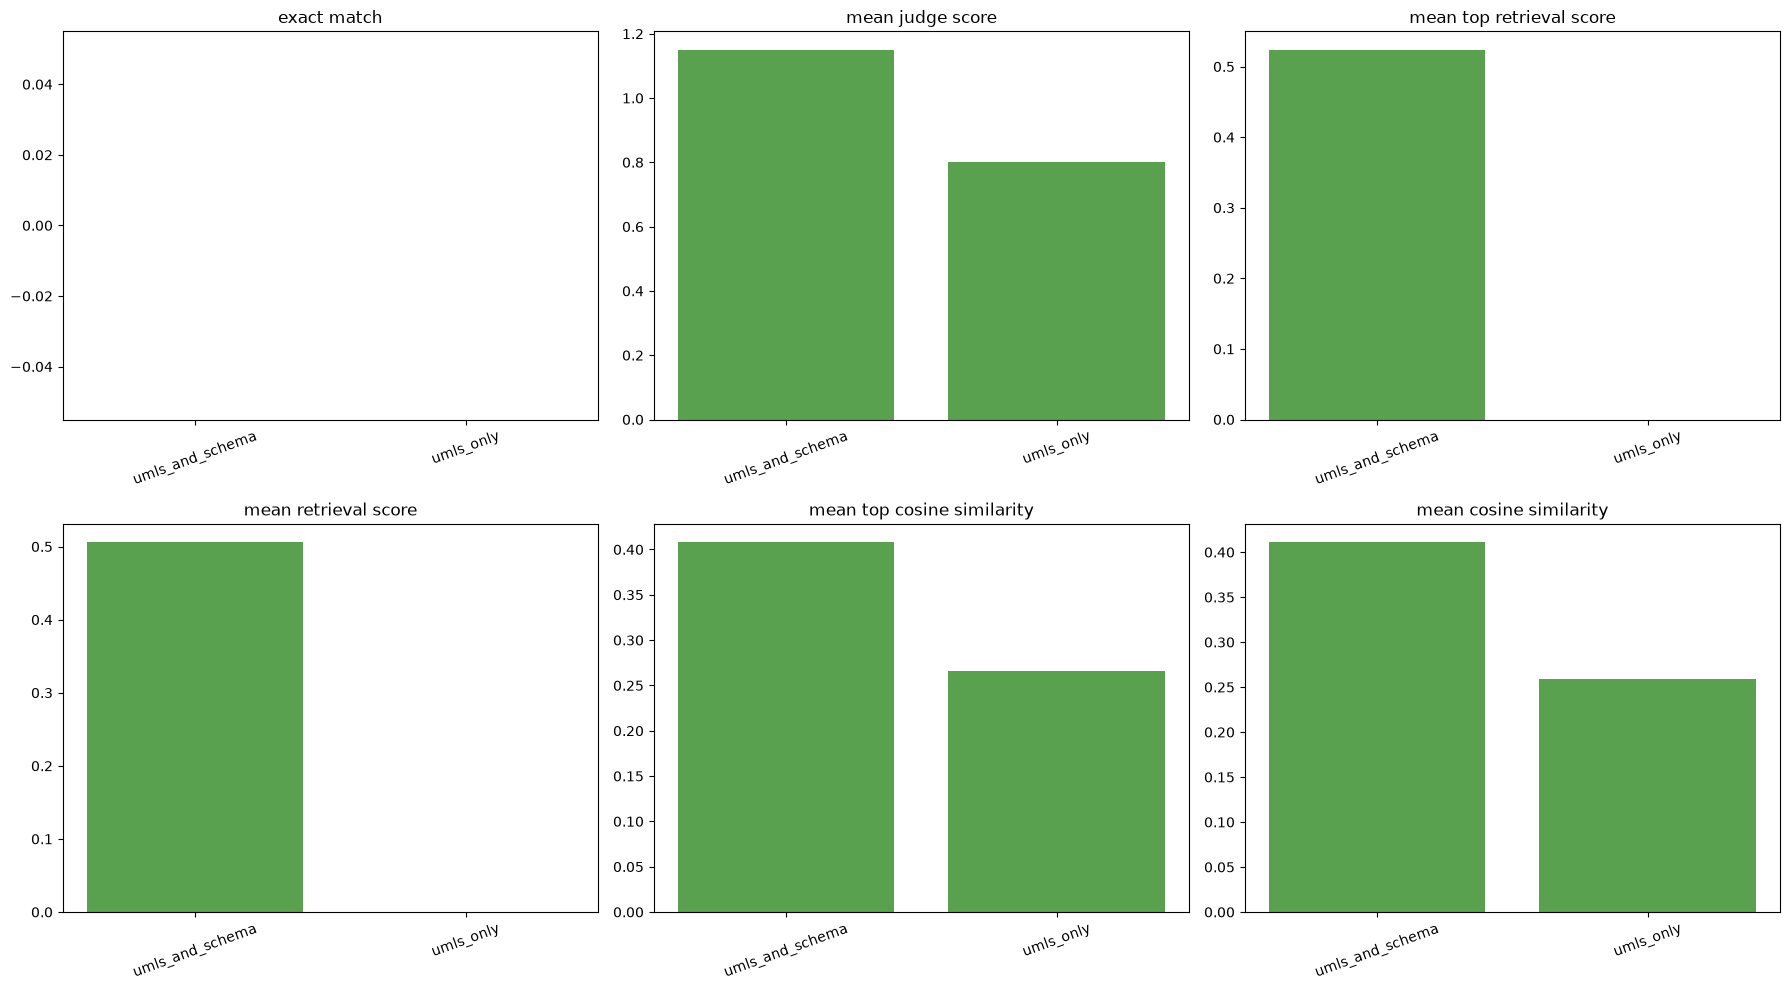

,condition,node_count,edge_count,density,component_count,largest_component_share,isolate_count,isolate_share,entity_type_count,question_count,exact_match,mean_judge_score,mean_source_count,mean_top_retrieval_score,mean_retrieval_score,mean_retrieval_score_margin,mean_top_cosine_similarity,mean_cosine_similarity,mean_cosine_similarity_margin
0,umls_and_schema,49,161,0.1369,2,0.9592,0,0.0,6,10,0.0,1.15,4.5,0.523742,0.505812,0.011358,0.407898,0.410939,-0.024020
1,umls_only,49,159,0.1352,2,0.9592,0,0.0,6,10,0.0,0.80,30.0,0.000000,0.000000,0.000000,0.266115,0.259184,0.008873


In [6]:
metric_columns = [
    "exact_match",
    "mean_judge_score",
    "mean_top_retrieval_score",
    "mean_retrieval_score",
    "mean_top_cosine_similarity",
    "mean_cosine_similarity",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for axis, column in zip(axes.flat, metric_columns):
    axis.bar(benchmark_df["condition"], benchmark_df[column], color="#59a14f")
    axis.set_title(column.replace("_", " "))
    axis.tick_params(axis="x", rotation=20)
fig.tight_layout()
benchmark_metrics_path = save_figure(fig, "04_benchmark_metrics")
plt.show()

combined_df = graph_stats_df.merge(benchmark_df, on="condition", how="inner")
combined_df.to_csv(OUTPUT_ROOT / "condition_summary.csv", index=False)
combined_csv_path, combined_html_path = save_dataframe_artifacts(combined_df, "condition_summary")
add_report_section(
    "Condition Summary",
    f"<p><img src='{report_rel(benchmark_metrics_path)}' alt='Benchmark metrics'></p>"
    f"<p><a href='{report_rel(combined_html_path)}'>Condition summary table</a> | <a href='{report_rel(combined_csv_path)}'>CSV</a></p>",
)
combined_df


In [7]:
question_comparison_rows = []
for item in questions:
    question_text = str(item.get("question", ""))
    for label, frame in per_condition_results.items():
        match = frame.loc[frame["question"] == question_text].head(1)
        if match.empty:
            continue
        row = match.iloc[0]
        question_comparison_rows.append({
            "question": question_text,
            "condition": label,
            "predicted_answer": row.get("predicted_answer"),
            "exact_match": row.get("exact_match"),
            "judge_score": row.get("judge_score"),
            "judge_verdict": row.get("judge_verdict"),
            "judge_rationale": row.get("judge_rationale"),
            "top_retrieval_score": row.get("top_retrieval_score"),
            "top_cosine_similarity": row.get("top_cosine_similarity"),
            "response": row.get("response"),
            "context_preview": row.get("context_preview"),
        })

question_comparison_df = pd.DataFrame(question_comparison_rows)
question_winners_df = pd.DataFrame()
winner_summary_df = pd.DataFrame()

if not question_comparison_df.empty:
    display(Markdown(f"## Question Comparison\n\nComparing responses across {len(questions)} relevant MedQA questions with LLM-judge scoring against the reference answer."))
    question_comparison_df = question_comparison_df.sort_values(["question", "condition"]).reset_index(drop=True)
    question_winner_rows = []
    for question_text, frame in question_comparison_df.groupby("question", sort=False):
        winner = select_condition_winner(frame)
        for _, row in frame.iterrows():
            record = row.to_dict()
            record["winner"] = winner
            record["is_winner"] = bool(record["condition"] == winner)
            question_winner_rows.append(record)
    question_winners_df = pd.DataFrame(question_winner_rows)
    winner_summary_df = (
        question_winners_df.loc[question_winners_df["is_winner"]]
        .groupby("condition", as_index=False)
        .agg(question_wins=("question", "count"))
        .sort_values(["question_wins", "condition"], ascending=[False, True], kind="stable")
        .reset_index(drop=True)
    )

    question_comparison_csv_path, question_comparison_html_path = save_dataframe_artifacts(
        question_winners_df,
        "question_comparison"
    )
    winner_summary_csv_path, winner_summary_html_path = save_dataframe_artifacts(
        winner_summary_df,
        "question_winner_summary"
    )
    add_report_section(
        "Question Comparison",
        f"<p>Relevant MedQA questions compared across all graph conditions: {len(questions)}</p>"
        f"<p><a href='{report_rel(question_comparison_html_path)}'>Per-question comparison table</a> | <a href='{report_rel(question_comparison_csv_path)}'>CSV</a></p>"
        f"<p><a href='{report_rel(winner_summary_html_path)}'>Winner summary table</a> | <a href='{report_rel(winner_summary_csv_path)}'>CSV</a></p>",
    )

    display(winner_summary_df)
    display(question_winners_df)

report_path = write_report_html()
display(Markdown(f"Report written to `{report_path}`"))


## Question Comparison

Comparing responses across 10 relevant MedQA questions with LLM-judge scoring against the reference answer.

,condition,question_wins
0,umls_and_schema,10


,question,condition,predicted_answer,exact_match,judge_score,judge_verdict,judge_rationale,top_retrieval_score,top_cosine_similarity,response,context_preview,winner,is_winner
0,A 14-year-old obese boy presents with severe r...,umls_and_schema,Reassess in 3 months,0.0,0.5,Incorrect,The model answer completely misses the questio...,0.473729,0.313340,The provided clinical discharge notes discuss ...,Text [10000764_27897940_10000764-DS-11.txt]: H...,umls_and_schema,True
1,A 14-year-old obese boy presents with severe r...,umls_only,None,0.0,0.0,Incorrect,The model declined to answer the clinical ques...,0.000000,0.256189,I am unable to answer this query because the p...,Text: a0a467c6-00dc-49dd-ae1e-718d02572104 -> ...,umls_and_schema,False
2,A 34-year-old woman presents to the emergency ...,umls_and_schema,Decreased carbohydrate intake,0.0,0.5,Incorrect,The model incorrectly assesses the prompt by c...,0.511074,0.380694,"Based on the provided context information, the...",Text [10000826_21086876_10000826-DS-18.txt]: H...,umls_and_schema,True
3,A 34-year-old woman presents to the emergency ...,umls_only,None,0.0,0.5,Misaligned,The model answer fails entirely because it cla...,0.000000,0.287911,The provided context information does not cont...,Text: a0a467c6-00dc-49dd-ae1e-718d02572104 -> ...,umls_and_schema,False
4,A 36-year-old man is brought to the emergency ...,umls_and_schema,None,0.0,0.5,Not Answerable,The model correctly identifies that there is i...,0.568799,0.418665,(The provided context materials do not contain...,Text [10000935_21738619_10000935-DS-19.txt]: H...,umls_and_schema,True
5,A 36-year-old man is brought to the emergency ...,umls_only,None,0.0,0.5,Incorrect/Non-responsive,The model answer is completely irrelevant to t...,0.000000,0.214306,The provided information does not contain deta...,Text: a0a467c6-00dc-49dd-ae1e-718d02572104 -> ...,umls_and_schema,False
6,A 56-year-old man presents to the emergency de...,umls_and_schema,None,0.0,1.0,Incorrect,The question asks for the best treatment optio...,0.591948,0.517590,The provided materials do not contain enough i...,Text [10000032_29079034_10000032-DS-23.txt]: H...,umls_and_schema,True
7,A 56-year-old man presents to the emergency de...,umls_only,None,0.0,0.5,Incorrect,The model answer is completely inappropriate a...,0.000000,0.292471,I am unable to determine the best treatment op...,Text: a0a467c6-00dc-49dd-ae1e-718d02572104 -> ...,umls_and_schema,False
8,A 62-year-old man presents with episodes of pa...,umls_and_schema,Begin aspirin therapy,0.0,1.0,Incorrect,The clinical scenario describes a patient with...,0.517168,0.390981,A. Begin aspirin therapy,Text [10000980_20897796_10000980-DS-26.txt]: H...,umls_and_schema,True
9,A 62-year-old man presents with episodes of pa...,umls_only,None,0.0,0.5,Insufficient Information,The model correctly identifies that essential ...,0.000000,0.285563,The necessary information to determine the mos...,Text: a0a467c6-00dc-49dd-ae1e-718d02572104 -> ...,umls_and_schema,False


Report written to `output/umls_schema_comparison/report/index.html`